In [91]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random as random
from collections import deque

### Color Schema

- Green -> Tree (0)
- Gray -> Open Path (1)
- Black -> Wall (2)
- Yellow -> Quicksand (3)
- Red -> Hole (4)
- Blue -> Gate(5)

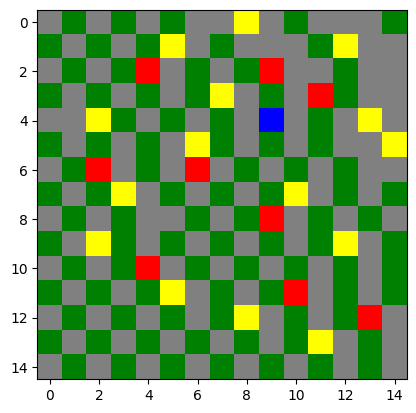

In [92]:


grid_map = np.array([
    [1, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1, 0, 2, 1, 1],
    [1, 0, 1, 0, 3, 1, 0, 1, 0, 3, 1, 1, 0, 1, 1],
    [0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 3, 0, 1, 1],
    [1, 1, 2, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1, 2, 1],
    [0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2],
    [1, 0, 3, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 1],
    [0, 1, 0, 2, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 0],
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 3, 1, 0, 1, 0, 1],
    [0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0],
    [1, 0, 1, 0, 3, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 2, 1, 0, 1, 0, 3, 1, 0, 1, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 0, 3, 1],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
])
colors = ['green', 'grey', 'black', 'yellow', 'red', 'blue']
cmap = ListedColormap(colors)
plt.imshow(grid_map, cmap = cmap, vmin = 0, vmax = 4)

- Too Many Blocked Paths

In [93]:
obstacles = [0 , 2, 3 , 4]
passable = [1,3] #obstacles which allow passage

#House Walls
vertical_wall = [(1,16),(2,16),(3,16),(4,16)]
horizontal_wall = [(4,16),(4,17),(4,18)]

BFS for checking neighbor connectivity

In [94]:
def bfs(grid, chosen , passable_neighbors,x,y):
    queue = deque([chosen]) #putting the source
    visited = {chosen}  #add all what we visited to this array, set of coordinates 
    #We need to temporarily block the {x,y} tile, so that the system doesn't mistake it for a path
    grid[x,y] = 2
    while queue:
        cx, cy = queue.popleft()
        
        #We need to explore its direct neighbors
        for dnx, dny in [(-1,0),(1,0),(0,-1),(0,1)]:
            #check if already visited
            if((cx+dnx,cy+dny) in visited):
                continue
            #check if passable
            if(grid[cx+dnx,cy+dny] not in passable):
                continue
            #check if in the neighbors 
            if((cx+dnx,cy+dny) in passable_neighbors):
                grid[x,y] = 1 #Unblock it
                return True
            #neither of both, we add it as visited and we add it to the queue
            queue.append((cx+dnx,cy+dny))
            visited.add((cx+dnx,cy+dny))
        
    grid[x,y] = 1
    return False

Function that builds edge walls, room walls and installs gate

In [95]:
def build_wall(grid):
    #Creating walls around the map
    grid[0, :] = 2
    grid[: , 0] = 2
    grid[-1, : ] = 2
    grid[:, -1] = 2
    #building the walls
    for x,y in horizontal_wall:
        grid[x,y] = 2
    for x,y in vertical_wall:
        grid[x,y] = 2
    #Installing the gate
    coords = random.choice([(2,16),(3,16)]) #gate coords
    grid[coords[0],coords[1]] = 5



Function that chooses the obstacle: 
- No more than 5% of tile counts should be a hole

In [96]:
def choose_obstacle(hole_count, gridsize):
    while(True):
            obstacle = random.choice(obstacles)
            if obstacle == 4:
                #check hole counter
                if hole_count == int(gridsize[0]*gridsize[1]*0.05) :
                    continue
                else:
                    hole_count+=1
                    break;
            else:
                break
    return obstacle

Main Builder Function

In [97]:
def build_grid():
    gridsize = (20,20)
    hole_count = 0 #A map cannot have more 5% of it as holes. 
    
    grid = np.ones(gridsize) #Create a grid, initially all passable
    #Building walls
    build_wall(grid)
    blocked_count = int(gridsize[0]*gridsize[1]*0.40) #40% of the grid must be blocked
    
    while blocked_count > 0 :
        #picking x and y by avoiding the edges
        x = random.randint(1,grid.shape[0]-2) 
        y = random.randint(1,grid.shape[1]-2)
        if (x,y) in vertical_wall or (x,y) in horizontal_wall:
            continue
        #making sure , the hole count does not exceed 5% of the map grid count
        obstacle = choose_obstacle(hole_count,gridsize)
        #Direct Neighbors
        up = (x-1,y)
        down = (x+1,y)
        left = (x,y-1)
        right = (x,y+1)
        temp = [up,down,left,right]
        check = [1 if  grid[n[0],n[1]] == 5 else 0 for n in temp]
        if sum(check) != 0:
            continue;    
        #It is prohibited for any obstacle of any kind to block the gate.
        
        if obstacle == 3:
            grid[x,y] = 3
            blocked_count-=1
        else: #obstacle NOT passable
            
            count = 0 #passable neigbors count
            passable_neigbors = [] #store all the passable neighbors
            
            for neighbor in temp:
                if grid[neighbor[0], neighbor[1]] in passable:
                    passable_neigbors.append((neighbor[0], neighbor[1]))
                    count+=1
                
            if count < 2:
                #safe to add the obstacle
                grid[x,y] = obstacle
                blocked_count-=1
            elif count >= 2:
                #choose a random neighbor and check the connectivity between all passable neighbors
                chosen = random.choice(passable_neigbors)
                state = bfs(grid,chosen,passable_neigbors,x,y)
                if state:
                    #safe to add
                    grid[x,y] = obstacle
                    blocked_count-=1
    return grid

This function will clear a 2 tile space around the house to ensure passability. It will also clean the inner area of the house of any obstacles.

In [98]:
def clean_grid(grid):
    #clean outside
    for x,y in vertical_wall:
        grid[x,y-1] = 1
        grid[x,y-2] = 1
        if x!=4:
            grid[x,y+1] = 1
            grid[x,y+2] = 1
    for x,y in horizontal_wall:
        grid[x+1,y] = 1
        grid[x+2,y] = 1
    
    

In [ ]:
def create_grid():
    grid = build_grid()
    clean_grid(grid)
    #Grid validator function placeholder
    return grid

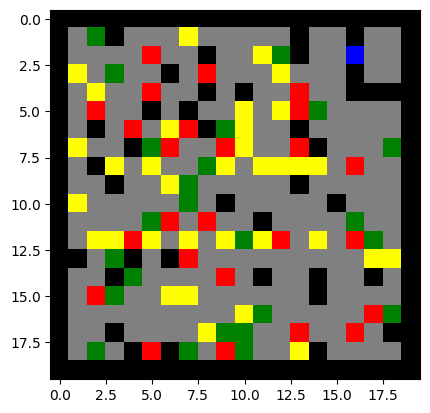

In [101]:
grid = create_grid()
plt.imshow(grid, cmap = cmap, vmin = 0, vmax = 5)